In [2]:
%matplotlib widget

from matplotlib import pyplot as plt
from matplotlib import animation
import numpy as np
from scipy import integrate
import matplotlib.animation as animation
from functools import partial
import control as ct
import ipywidgets as widgets

In [86]:
ThermalModelTransferFunction = ct.tf([25], [350, 1])
type(ThermalModelTransferFunction)
isinstance(ThermalModelTransferFunction, ct.TransferFunction)
TherMoSS = ct.tf2ss(ThermalModelTransferFunction)
isinstance(TherMoSS, ct.StateSpace)
u_in = np.linspace(1,1,3) *  TherMoSS.C[0,0]
sol = ct.forced_response(TherMoSS, [0,25,50], u_in, [10])
x_init = np.zeros(np.shape(TherMoSS.B))
x_init =  sol.outputs / TherMoSS.C[0,0]
print(x_init)

[10.        11.0340583 11.9968315]


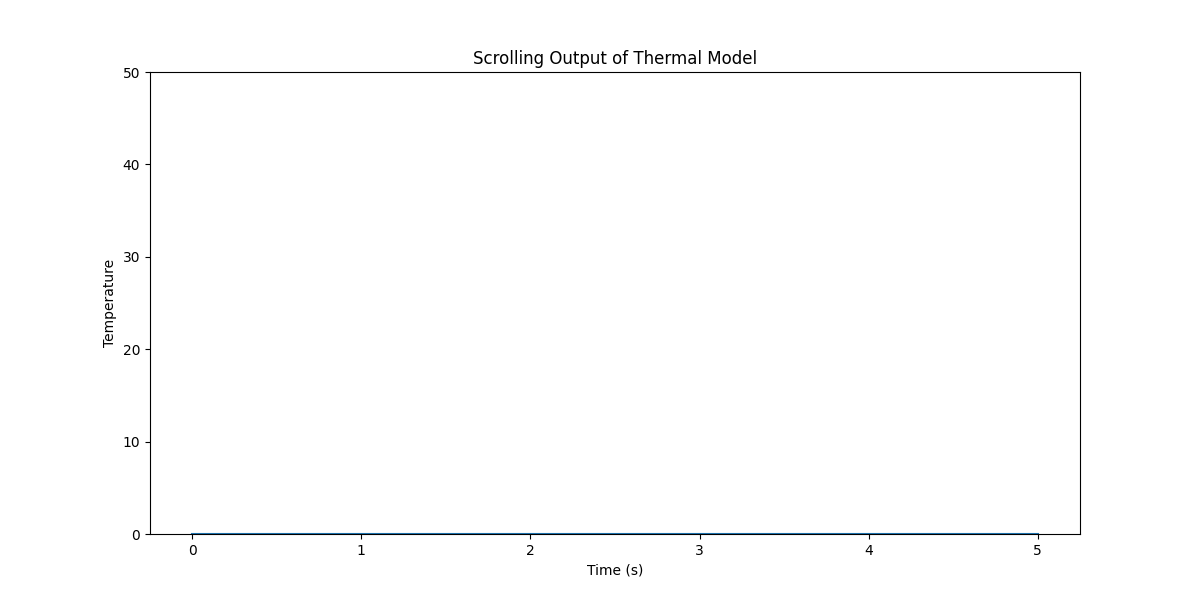

In [ ]:

ani = None
window_length = 5     # seconds
dt = 0.1              # seconds
T_amb = 22            # Ambient temperature
  
class Past_inputs_anim:
    """
    Animates the output of a dynamic model over a moving time window.
    Uses solve_ivp for full model flexibility.
    """

    def __init__(self, line, ax, model_function, window_length=10, dt=0.1):

        self.line = line
        self.ax = ax
        self.model_function = model_function

        self.dt = dt
        self.window_samples = int(window_length / dt)
        self.N = self.window_samples

        self.history = np.ones(self.N)*T_amb
        self.ptr = 0

        self.state = np.array([20.0])  # initial state (must be array for solve_ivp)
        self.current_time = 0.0

    def init_plot(self):
        self.line.set_ydata(np.zeros(self.N))
        return self.line,

    def step(self):
        """
        Advances system by one dt using solve_ivp.
        Keeps implementation fully general.
        """

        time_solve = np.linspace(self.current_time, self.current_time+self.dt, 2) #solve as small step between start- and end point
        u_simulate = [10, 10] []#self.u*time_solve
        # display(time_solve)
        t_out, sol = ct.forced_response(self.model_function, time_solve, u_simulate, self.state[-1])

        self.current_time += self.dt
        self.state = sol            # works for multi-state systems

        return self.state[-1]                 # assuming 1 state for plotting

    def update_history(self, u):

        output = self.step(u)

        self.history[self.ptr] = output
        self.ptr = (self.ptr + 1) % self.N

        # Chronological order reconstruction
        y_full = np.concatenate(
            (self.history[self.ptr:], self.history[:self.ptr])
        )

        return y_full

    def animate(self, i):

        # Example time-varying input

        y_window = self.update_history(10)

        x_window = np.linspace(
            self.current_time - len(y_window)*self.dt,
            self.current_time,
            len(y_window)
        )

        self.line.set_data(x_window, y_window)
        self.ax.set_xlim(x_window[0], x_window[-1])

        return self.line,


def run_animation(model_function, window_length=5, dt=0.1):
    global ani

    if ani is not None:
        ani.event_source.stop()

    plt.close("all")

    fig, ax = plt.subplots(figsize=(12, 6))

    line, = ax.plot(
        np.linspace(0, window_length, int(window_length/dt)),
        np.zeros(int(window_length/dt))
    )

    ax.set_ylim(-5, 50)
    ax.set_title("Scrolling Output of Thermal Model")
    ax.set_xlabel("Time (s)")
    ax.set_ylabel("Temperature")

    state = Past_inputs_anim(
        line,
        ax,
        model_function,
        window_length=window_length,
        dt=dt
    )

    ani = animation.FuncAnimation(
        fig,
        state.animate,
        init_func=state.init_plot,
        save_count = 10,
        interval=int(dt*1000),
        blit=True
    )

    plt.show()

# Run animation
# u_slider = widgets.FloatSlider(value=0.0, min=0, max=25, step=0.1, description='u_in')
# display(u_slider)
run_animation(ThermalModelTransferFunction)

In [4]:
t_resp, x_resp = ct.forced_response(ThermalModelTransferFunction, np.linspace(0, 1), np.sin(np.linspace(0, 1)))
np.shape(x_resp)

(50,)